# 20 -  Skill Specialisation & Ecosystem Mapping  
**Notebook purpose:** Interpreting structural outputs from job–skill embeddings  

This notebook provides the **interpretability layer** for Chapter 2 of the Job Intelligence Engine.  
While earlier components of the chapter focus on *constructing* structural artefacts—graphs, embeddings, job families, and similarity networks—this notebook focuses on *reading* those artefacts to understand how skills are organised across the labour market.

The central goal is to move from abstract latent structure to **meaningful patterns of specialisation**, answering questions such as:
- Which skills are over- or under-represented in different parts of the market?
- How do skill bundles differ by job family, sector, title, or organisation type?
- Where do genuinely specialised ecosystems emerge, as opposed to generic skill demand?

---

## From Structural Geometry to Skill Interpretation

Chapter 2 represents the labour market as a relational system rather than a set of independent features. Jobs and skills are embedded in a shared latent space based on their co-occurrence structure in the job–skill graph. However, embeddings alone are not directly interpretable: distances encode similarity, but not *direction* or *meaning*.

This notebook bridges that gap by translating structural proximity into **skill specialisation profiles**. Instead of clustering skills or forcing discrete labels, it asks a simpler and more robust question:  
> *Relative to the market as a whole, which skills are unusually common (or rare) within a given group of jobs?*

This framing preserves the continuous nature of the embeddings while yielding interpretable signals.

---

## Skill Lift as a Measure of Specialisation

The core analytical construct used here is **skill lift**.  
For each grouping of interest (e.g. job family, sector, title, ownership type), we compute:

- the **global mean skill probability** across all jobs, and  
- the **group-specific mean skill probability**.

The difference between the two defines a lift value:
- **Positive lift** → skill is over-represented in that group (specialised demand)  
- **Negative lift** → skill is under-represented  
- **Near-zero lift** → generic or background skill

This approach ensures that specialisation is defined *relative to the entire market*, not in absolute terms, avoiding confounding by overall skill prevalence.

---

## Why These Groupings?

The notebook focuses primarily on **structural groupings that plausibly shape skill demand**:
- **Job families** (derived from embeddings): latent ecosystems of similar roles  
- **Sector and enriched job title**: primary drivers of task composition  
- **Organisation attributes** (ownership, size): institutional context rather than task definition  

Geographic variables are intentionally deprioritised here. While location strongly affects salary (Chapter 1), it is not expected to meaningfully redefine *which* skills are required once role and sector are accounted for. This separation keeps the analysis aligned with its structural purpose.

---

## Role in the Overall Project

This notebook completes Chapter 2 by converting learned structure into **interpretable ecosystem summaries**.  
It does not introduce new models, nor does it optimise outcomes. Instead, it:

- validates that the learned embeddings encode coherent skill structure,  
- reveals how different parts of the labour market specialise, and  
- produces reusable artefacts (skill specialisation tables and heatmaps) that can be referenced in later chapters.

Downstream components—such as recommendation systems, pathway modelling, or competitiveness analysis—will build on these insights, but Chapter 2 itself remains focused on **structural discovery rather than decision-making**.

In short, this notebook answers the question:
> *Given the structure we learned, what does the labour market actually look like in terms of skill ecosystems?*


## Set Up

### Libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
#===
import sys
from pathlib import Path

# Path

In [2]:
project_root = Path().resolve().parent.parent
sys.path.append(str(project_root))
project_root

PosixPath('/Users/alejandrofp/Desktop/Projects/03_Flagship_Portfolio/job-intelligence-engine')

### Load and check data

In [3]:
OUT_DIR = project_root / "docs/narrative/figures/ch2_specialisation_map"

In [4]:
from src.job_intel.config import CH2_PROCESSED_DF
df = pd.read_csv(CH2_PROCESSED_DF)
skill_prob = pd.read_csv('/Users/alejandrofp/Desktop/Projects/03_Flagship_Portfolio/job-intelligence-engine/data/processed/skill_prob_matrix.csv')
job_families = pd.read_csv('/Users/alejandrofp/Desktop/Projects/03_Flagship_Portfolio/job-intelligence-engine/data/processed/job_families_graph_embeddings.csv')
job_families = job_families.drop(columns=["Unnamed: 0"])
job_families = job_families.set_index("job_id")

In [5]:
# Checks
assert job_families.index.is_unique
assert job_families.index.name == "job_id"
assert job_families.index.equals(skill_prob.index)

In [6]:
base = df.merge(job_families, on="job_id", how="inner").merge(skill_prob, on="job_id", how="inner")

In [7]:
print(f'Lenght pass: {len(base) == len(df) == len(skill_prob) == len(job_families)}')
print(f'Uniqueness pas: {base["job_id"].is_unique}')
print(f'Missingness pass: {base['job_family_id'].isna().sum() == 0}')
print(f'Skill column pass: {len(skill_prob.columns)==27+1}')
print(f'Skill value pass: {(skill_prob >= 0).mean().mean() == 1}')
print(f'Base shape: {base.shape}')

Lenght pass: True
Uniqueness pas: True
Missingness pass: True
Skill column pass: True
Skill value pass: True
Base shape: (6161, 167)


## Global skill probability

In [8]:
skill_global = skill_prob.iloc[:,1:].mean(axis = 0)

skill_global_df = (
    skill_global
    .rename("global_mean_prob")
    .reset_index()
    .rename(columns={"index": "skill"})
)


In [9]:
skill_global_df

,skill,global_mean_prob
0,core_programming__basic_prob,0.576768
1,core_programming__intermediate_prob,0.113261
2,core_programming__advanced_prob,0.002108
3,data_engineering_pipelines__basic_prob,0.035023
4,data_engineering_pipelines__intermediate_prob,0.391436
5,data_engineering_pipelines__advanced_prob,0.238512
6,ml_ai__basic_prob,0.230366
7,ml_ai__intermediate_prob,0.217726
8,ml_ai__advanced_prob,0.093998
9,analytics_stats__basic_prob,0.661069


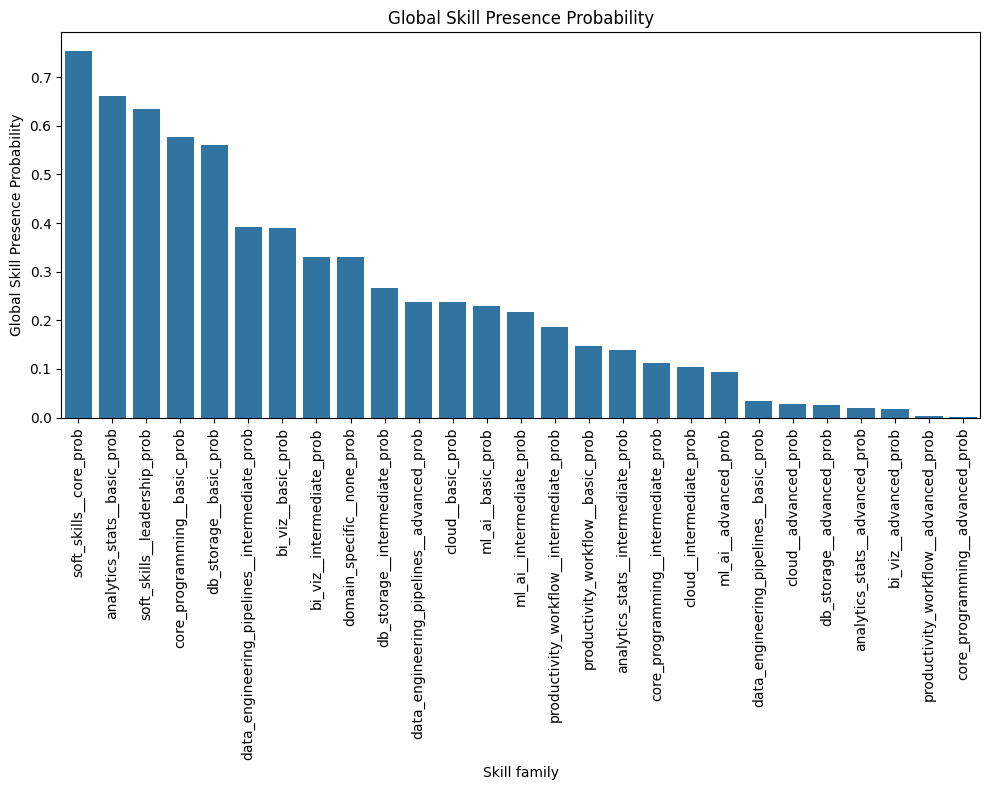

In [10]:
plt.figure(figsize=(10,8))
sns.barplot(
    data = skill_global_df.sort_values('global_mean_prob', ascending=False),
    x = 'skill',
    y = 'global_mean_prob'
)

plt.xticks(rotation = 90)
plt.xlabel("Skill family")
plt.ylabel("Global Skill Presence Probability")
plt.title("Global Skill Presence Probability")
plt.tight_layout()
plt.savefig(OUT_DIR / "global_skill_probability.png", dpi=300, bbox_inches="tight")

## Skill probability by Job family

In [11]:
skill_cols = skill_global_df["skill"].tolist()

family_skill_means = (
    base
    .groupby("job_family_id")[skill_cols]
    .mean()
)


In [12]:
family_skill_means

,core_programming__basic_prob,core_programming__intermediate_prob,core_programming__advanced_prob,data_engineering_pipelines__basic_prob,data_engineering_pipelines__intermediate_prob,data_engineering_pipelines__advanced_prob,ml_ai__basic_prob,ml_ai__intermediate_prob,ml_ai__advanced_prob,analytics_stats__basic_prob,...,cloud__advanced_prob,db_storage__basic_prob,db_storage__intermediate_prob,db_storage__advanced_prob,productivity_workflow__basic_prob,productivity_workflow__intermediate_prob,productivity_workflow__advanced_prob,soft_skills__core_prob,soft_skills__leadership_prob,domain_specific__none_prob
job_family_id,,,,,,,,,,,,,,,,,,,,,
0,0.707077,0.030231,5.034244e-06,0.011515,0.259809,0.209278,0.449498,0.924791,0.068666,0.760504,...,0.003531,0.525604,0.131307,0.000038,0.050562,0.054326,0.000230,0.833831,0.607193,0.353438
1,0.751459,0.026387,2.612776e-06,0.042246,0.196271,0.095804,0.068844,0.045170,0.011565,0.588412,...,0.001032,0.674924,0.037784,0.000543,0.007345,0.017019,0.000033,0.585116,0.297775,0.081608
2,0.435146,0.009201,2.503284e-06,0.075736,0.333039,0.164913,0.127065,0.070852,0.009259,0.610275,...,0.000503,0.899185,0.778987,0.000230,0.116704,0.109302,0.002503,0.773322,0.543391,0.241302
3,0.559564,0.029538,1.901999e-02,0.012779,0.203813,0.167927,0.872471,0.113099,0.017882,0.643167,...,0.001466,0.308358,0.044798,0.000096,0.035970,0.027753,0.000039,0.770557,0.634941,0.369291
4,0.196735,0.002876,4.561351e-08,0.024711,0.072658,0.048886,0.032104,0.030466,0.000877,0.608103,...,0.000349,0.272911,0.029242,0.000242,0.010342,0.016314,0.000433,0.831716,0.708165,0.117442
5,0.868353,0.369757,8.347735e-03,0.033963,0.880987,0.515731,0.208622,0.177126,0.038497,0.746440,...,0.015498,0.684635,0.548377,0.004911,0.184171,0.438293,0.000002,0.754596,0.692638,0.322632
6,0.911762,0.139742,2.932607e-03,0.008967,0.476109,0.433539,0.774253,0.826726,0.938612,0.807806,...,0.022464,0.463892,0.237640,0.003141,0.266207,0.188889,0.011828,0.804340,0.563393,0.317364
7,0.488467,0.006388,1.209777e-07,0.037185,0.228294,0.106138,0.055614,0.037271,0.002295,0.744017,...,0.000195,0.787751,0.055227,0.000889,0.008467,0.031803,0.008937,0.767094,0.652456,0.219157
8,0.663757,0.065374,1.720101e-06,0.025382,0.277119,0.131620,0.340382,0.349197,0.030774,0.752681,...,0.002032,0.619794,0.177099,0.000745,0.067416,0.114674,0.000036,0.800458,0.651729,0.323027


## Specialisation map - LIFT-

In [13]:
family_skill_lift = family_skill_means.subtract(
    skill_global,
    axis=1
)


In [14]:
family_skill_lift

,core_programming__basic_prob,core_programming__intermediate_prob,core_programming__advanced_prob,data_engineering_pipelines__basic_prob,data_engineering_pipelines__intermediate_prob,data_engineering_pipelines__advanced_prob,ml_ai__basic_prob,ml_ai__intermediate_prob,ml_ai__advanced_prob,analytics_stats__basic_prob,...,cloud__advanced_prob,db_storage__basic_prob,db_storage__intermediate_prob,db_storage__advanced_prob,productivity_workflow__basic_prob,productivity_workflow__intermediate_prob,productivity_workflow__advanced_prob,soft_skills__core_prob,soft_skills__leadership_prob,domain_specific__none_prob
job_family_id,,,,,,,,,,,,,,,,,,,,,
0,0.130309,-0.083030,-0.002103,-0.023508,-0.131626,-0.029235,0.219132,0.707065,-0.025332,0.099435,...,-0.024301,-0.034144,-0.135531,-0.025948,-0.097100,-0.131935,-0.002546,0.079511,-0.027027,0.023729
1,0.174690,-0.086874,-0.002105,0.007223,-0.195164,-0.142708,-0.161521,-0.172556,-0.082433,-0.072656,...,-0.026799,0.115176,-0.229055,-0.025443,-0.140318,-0.169242,-0.002742,-0.169203,-0.336444,-0.248101
2,-0.141622,-0.104061,-0.002105,0.040713,-0.058396,-0.073599,-0.103300,-0.146874,-0.084739,-0.050794,...,-0.027329,0.339437,0.512148,-0.025757,-0.030958,-0.076958,-0.000272,0.019003,-0.090829,-0.088406
3,-0.017205,-0.083724,0.016912,-0.022244,-0.187623,-0.070585,0.642106,-0.104627,-0.076116,-0.017901,...,-0.026365,-0.251390,-0.222040,-0.025891,-0.111693,-0.158508,-0.002736,0.016238,0.000721,0.039582
4,-0.380033,-0.110385,-0.002108,-0.010312,-0.318777,-0.189626,-0.198262,-0.187259,-0.093121,-0.052966,...,-0.027482,-0.286837,-0.237597,-0.025744,-0.137321,-0.169947,-0.002342,0.077397,0.073945,-0.212267
5,0.291585,0.256496,0.006240,-0.001060,0.489551,0.277219,-0.021744,-0.040599,-0.055501,0.085371,...,-0.012334,0.124887,0.281539,-0.021076,0.036509,0.252032,-0.002773,0.000277,0.058418,-0.007076
6,0.334993,0.026481,0.000825,-0.026055,0.084674,0.195027,0.543887,0.609000,0.844614,0.146738,...,-0.005367,-0.095857,-0.029199,-0.022845,0.118545,0.002629,0.009053,0.050021,-0.070826,-0.012345
7,-0.088301,-0.106874,-0.002108,0.002162,-0.163142,-0.132374,-0.174752,-0.180455,-0.091703,0.082948,...,-0.027637,0.228003,-0.211611,-0.025097,-0.139195,-0.154458,0.006162,0.012775,0.018236,-0.110551
8,0.086989,-0.047887,-0.002106,-0.009641,-0.114317,-0.106892,0.110016,0.131471,-0.063224,0.091612,...,-0.025800,0.060046,-0.089739,-0.025241,-0.080247,-0.071587,-0.002739,0.046138,0.017509,-0.006682


In [15]:
family_skill_lift.loc[0].sort_values(ascending=False).head(5)

ml_ai__intermediate_prob        0.707065
ml_ai__basic_prob               0.219132
core_programming__basic_prob    0.130309
analytics_stats__basic_prob     0.099435
soft_skills__core_prob          0.079511
Name: 0, dtype: float64

### Save data

In [16]:
from src.job_intel.config import PROCESSED_DATA_DIR
family_skill_lift.to_csv(PROCESSED_DATA_DIR / "job_family_skill_specialisation.csv")

At this stage, we have assembled the core structural outputs of Chapter 2. Starting from the Chapter 1 job × skill probability matrix, we constructed a probability-weighted job–skill bipartite graph and learned Node2Vec embeddings for both jobs and skills. Job embeddings were then normalised and clustered to infer latent job families, providing a compact structural index of the labour market. In parallel, skill embeddings were used to derive a sparse skill-similarity network, capturing relational proximity between skills without forcing hard clusters. Finally, we aggregated skill probabilities by job family and compared them to global averages to compute a job-family skill specialisation map, which quantifies over- and under-represented skills within each latent ecosystem. Together, these artefacts establish the structural backbone needed for interpretation, ecosystem analysis, and downstream recommendation modules.

## Grouping Skill Map
* 'Size'
* 'Sector'
* 'state'
* 'ownership_clean'
* 'seniority_combined'
* 'title_rich'
* 'job_title_family'


### Size

In [17]:
size_skill_means = (
    base
    .groupby("Size")[skill_cols]
    .mean()
)
size_skill_lift = size_skill_means.subtract(
    skill_global,
    axis=1
)

<Figure size 1000x1000 with 0 Axes>

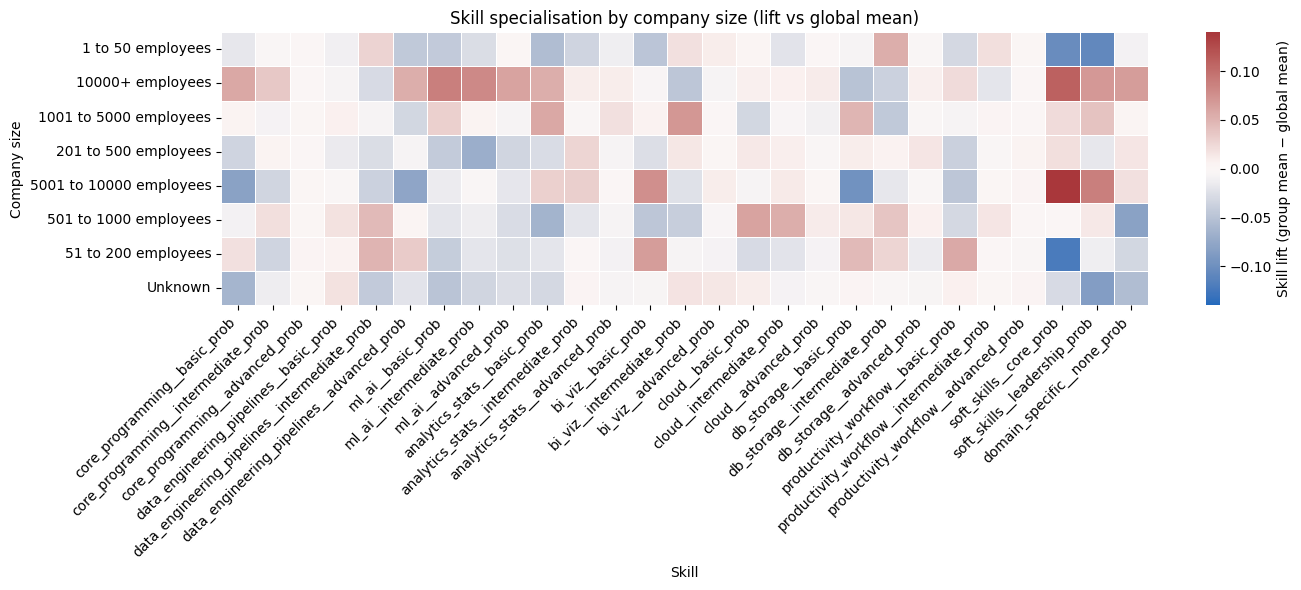

In [18]:
plt.figure(figsize=(10,10))
vmax = size_skill_lift.abs().to_numpy().max()
vmin = -vmax

plt.figure(figsize=(14, 6))
ax = sns.heatmap(
    size_skill_lift,
    center=0,
    vmin=vmin,
    vmax=vmax,
    cmap="vlag",          # diverging map; switch if you prefer
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Skill lift (group mean − global mean)"},
)

ax.set_title("Skill specialisation by company size (lift vs global mean)")
ax.set_xlabel("Skill")
ax.set_ylabel("Company size")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(OUT_DIR / "company_size_skill_probability_heatmap.png", dpi=300, bbox_inches="tight")

In [19]:
from src.job_intel.config import PROCESSED_DATA_DIR
size_skill_lift.to_csv(PROCESSED_DATA_DIR / "company_size_skill_specialisation.csv")

### Sector

In [20]:
sector_skill_means = (
    base
    .groupby("Sector")[skill_cols]
    .mean()
)
sector_skill_lift = sector_skill_means.subtract(
    skill_global,
    axis=1
)

from src.job_intel.config import PROCESSED_DATA_DIR
sector_skill_lift.to_csv(PROCESSED_DATA_DIR / "sector_skill_specialisation.csv")

<Figure size 1000x1000 with 0 Axes>

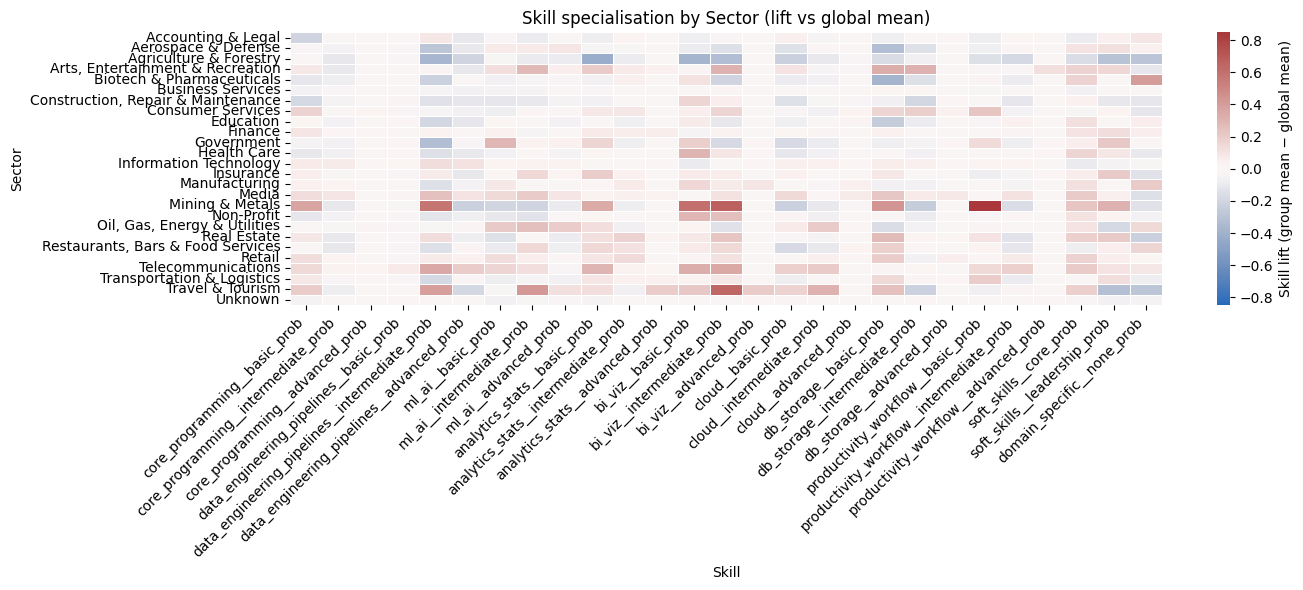

In [21]:
plt.figure(figsize=(10,10))
vmax = sector_skill_lift.abs().to_numpy().max()
vmin = -vmax

plt.figure(figsize=(14, 6))
ax = sns.heatmap(
    sector_skill_lift,
    center=0,
    vmin=vmin,
    vmax=vmax,
    cmap="vlag",          # diverging map; switch if you prefer
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Skill lift (group mean − global mean)"},
)

ax.set_title("Skill specialisation by Sector (lift vs global mean)")
ax.set_xlabel("Skill")
ax.set_ylabel("Sector")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(OUT_DIR / "sector_skill_probability_heatmap.png", dpi=300, bbox_inches="tight")

### State

In [22]:
state_skill_means = (
    base
    .groupby("state")[skill_cols]
    .mean()
)
state_skill_lift = state_skill_means.subtract(
    skill_global,
    axis=1
)

from src.job_intel.config import PROCESSED_DATA_DIR
state_skill_lift.to_csv(PROCESSED_DATA_DIR / "state_skill_specialisation.csv")

<Figure size 1000x1000 with 0 Axes>

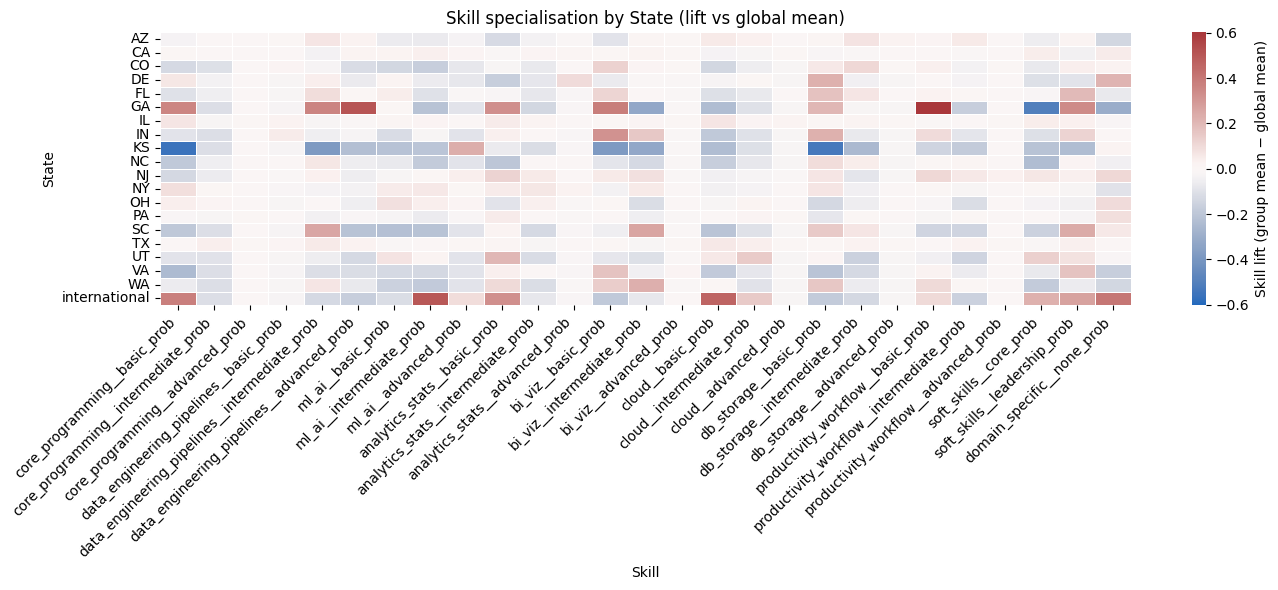

In [23]:
plt.figure(figsize=(10,10))
vmax = state_skill_lift.abs().to_numpy().max()
vmin = -vmax

plt.figure(figsize=(14, 6))
ax = sns.heatmap(
    state_skill_lift,
    center=0,
    vmin=vmin,
    vmax=vmax,
    cmap="vlag",          # diverging map; switch if you prefer
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Skill lift (group mean − global mean)"},
)

ax.set_title("Skill specialisation by State (lift vs global mean)")
ax.set_xlabel("Skill")
ax.set_ylabel("State")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(OUT_DIR / "state_skill_probability_heatmap.png", dpi=300, bbox_inches="tight")

### Ownership

In [24]:
ownership_skill_means = (
    base
    .groupby("ownership_clean")[skill_cols]
    .mean()
)
ownership_skill_lift = ownership_skill_means.subtract(
    skill_global,
    axis=1
)

from src.job_intel.config import PROCESSED_DATA_DIR
ownership_skill_lift.to_csv(PROCESSED_DATA_DIR / "ownership_skill_specialisation.csv")

<Figure size 1000x1000 with 0 Axes>

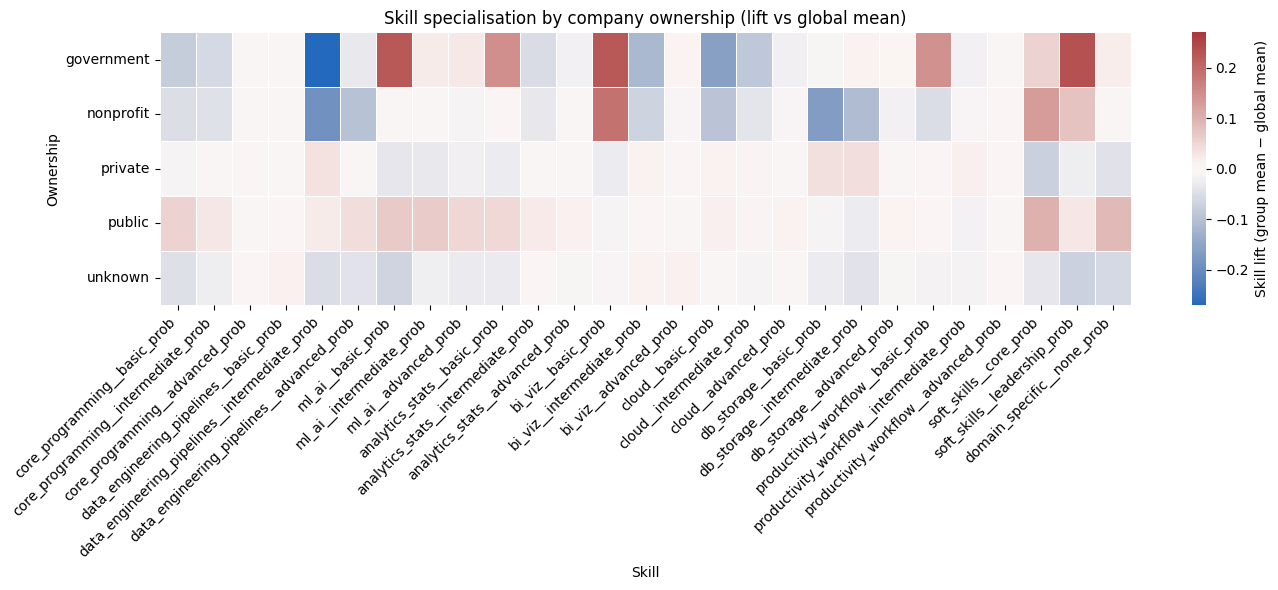

In [25]:
plt.figure(figsize=(10,10))
vmax = ownership_skill_lift.abs().to_numpy().max()
vmin = -vmax

plt.figure(figsize=(14, 6))
ax = sns.heatmap(
    ownership_skill_lift,
    center=0,
    vmin=vmin,
    vmax=vmax,
    cmap="vlag",          # diverging map; switch if you prefer
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Skill lift (group mean − global mean)"},
)

ax.set_title("Skill specialisation by company ownership (lift vs global mean)")
ax.set_xlabel("Skill")
ax.set_ylabel("Ownership")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(OUT_DIR / "ownership_skill_probability_heatmap.png", dpi=300, bbox_inches="tight")

### Seniority

In [26]:
seniority_skill_means = (
    base
    .groupby("seniority_combined")[skill_cols]
    .mean()
)
seniority_skill_lift = seniority_skill_means.subtract(
    skill_global,
    axis=1
)

from src.job_intel.config import PROCESSED_DATA_DIR
seniority_skill_lift.to_csv(PROCESSED_DATA_DIR / "seniority_skill_specialisation.csv")

<Figure size 1000x1000 with 0 Axes>

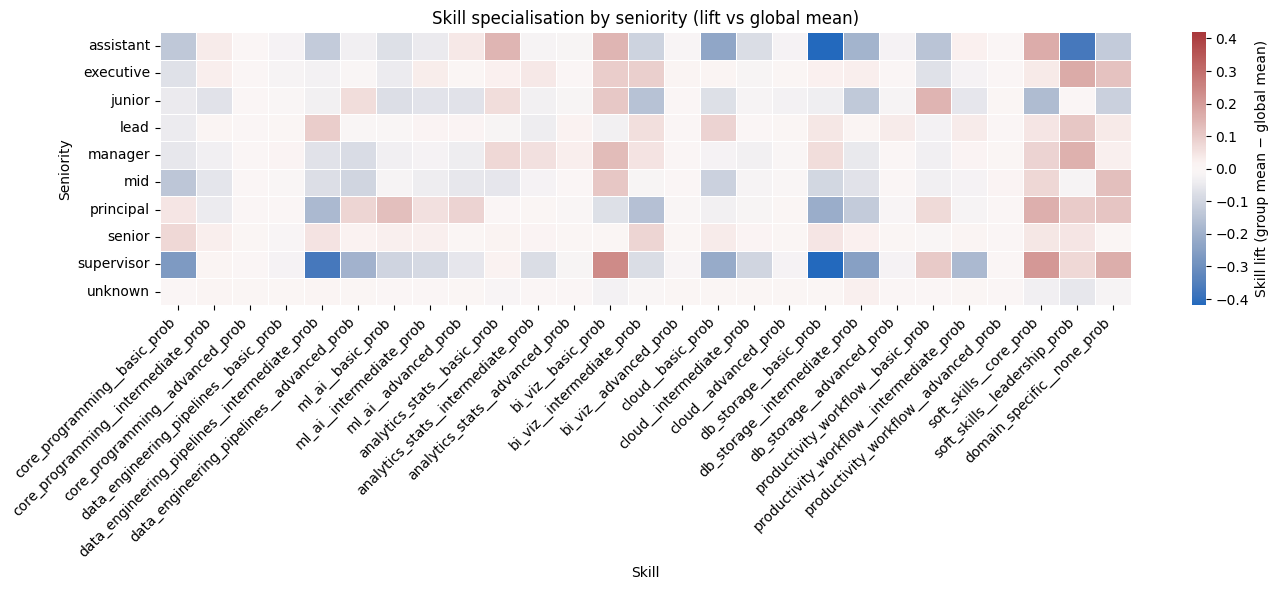

In [27]:
plt.figure(figsize=(10,10))
vmax = seniority_skill_lift.abs().to_numpy().max()
vmin = -vmax

plt.figure(figsize=(14, 6))
ax = sns.heatmap(
    seniority_skill_lift,
    center=0,
    vmin=vmin,
    vmax=vmax,
    cmap="vlag",          # diverging map; switch if you prefer
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Skill lift (group mean − global mean)"},
)

ax.set_title("Skill specialisation by seniority (lift vs global mean)")
ax.set_xlabel("Skill")
ax.set_ylabel("Seniority")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(OUT_DIR / "seniority_skill_probability_heatmap.png", dpi=300, bbox_inches="tight")

### Title

In [28]:
title_skill_means = (
    base
    .groupby("title_rich")[skill_cols]
    .mean()
)
title_skill_lift = title_skill_means.subtract(
    skill_global,
    axis=1
)

from src.job_intel.config import PROCESSED_DATA_DIR
title_skill_lift.to_csv(PROCESSED_DATA_DIR / "title_skill_specialisation.csv")

<Figure size 1000x1000 with 0 Axes>

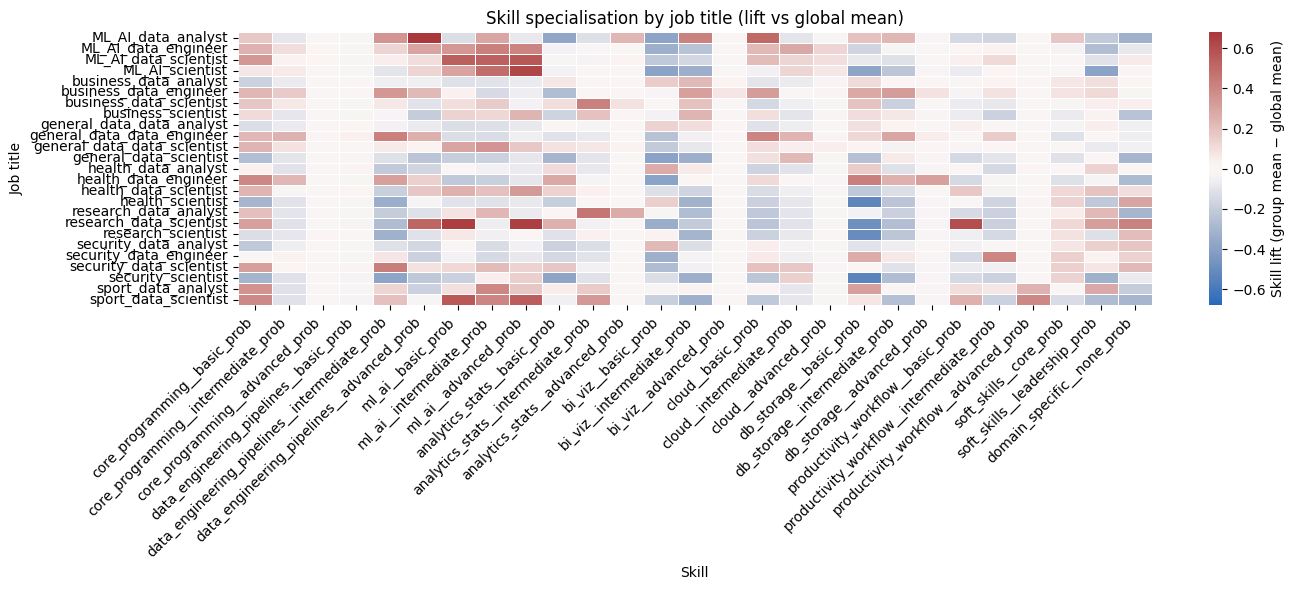

In [29]:
plt.figure(figsize=(10,10))
vmax = title_skill_lift.abs().to_numpy().max()
vmin = -vmax

plt.figure(figsize=(14, 6))
ax = sns.heatmap(
    title_skill_lift,
    center=0,
    vmin=vmin,
    vmax=vmax,
    cmap="vlag",          # diverging map; switch if you prefer
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Skill lift (group mean − global mean)"},
)

ax.set_title("Skill specialisation by job title (lift vs global mean)")
ax.set_xlabel("Skill")
ax.set_ylabel("Job title")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(OUT_DIR / "title_skill_probability_heatmap.png", dpi=300, bbox_inches="tight")

### Condensed title

In [30]:
title2_skill_means = (
    base
    .groupby("job_title_family")[skill_cols]
    .mean()
)
title2_skill_lift = title2_skill_means.subtract(
    skill_global,
    axis=1
)

from src.job_intel.config import PROCESSED_DATA_DIR
title2_skill_lift.to_csv(PROCESSED_DATA_DIR / "title_condensed_skill_specialisation.csv")

<Figure size 1000x1000 with 0 Axes>

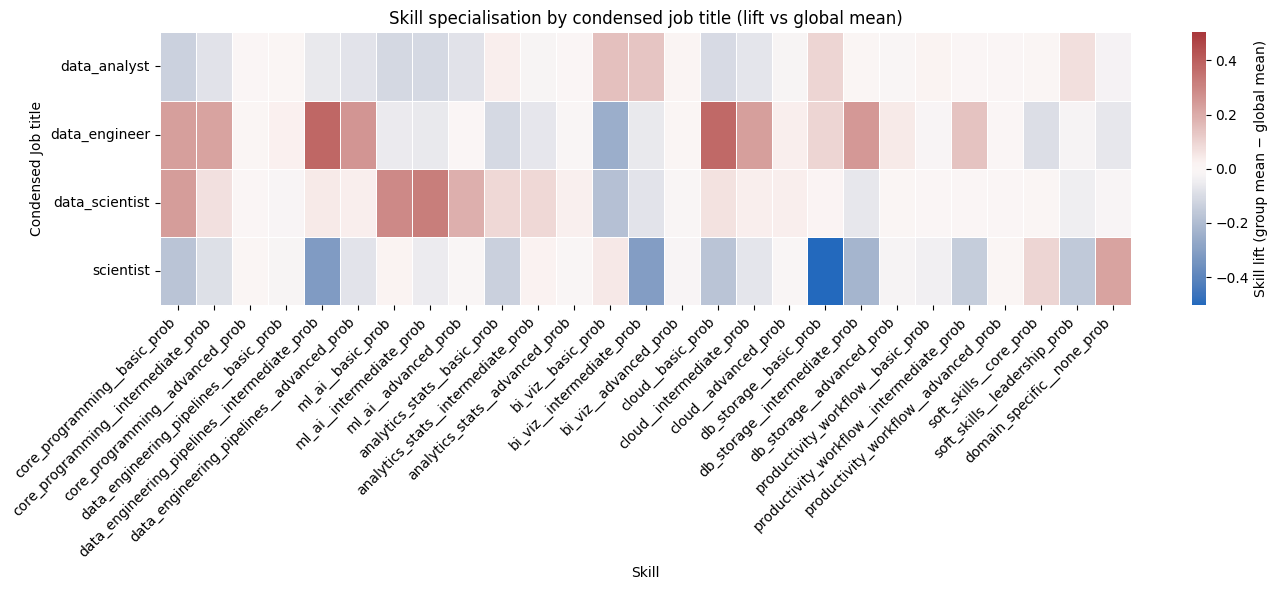

In [31]:
plt.figure(figsize=(10,10))
vmax = title2_skill_lift.abs().to_numpy().max()
vmin = -vmax

plt.figure(figsize=(14, 6))
ax = sns.heatmap(
    title2_skill_lift,
    center=0,
    vmin=vmin,
    vmax=vmax,
    cmap="vlag",          # diverging map; switch if you prefer
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Skill lift (group mean − global mean)"},
)

ax.set_title("Skill specialisation by condensed job title (lift vs global mean)")
ax.set_xlabel("Skill")
ax.set_ylabel("Condensed Job title")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(OUT_DIR / "title_condensed_skill_probability_heatmap.png", dpi=300, bbox_inches="tight")

## Skill Specialisation Maps (Lift-Based Analysis)

To interpret the structural outputs of Chapter 2, we compute **skill specialisation maps** by comparing group-level skill probabilities against the global skill baseline.  

For each categorical variable, we:
1. Compute the mean skill probability within each group.
2. Subtract the global mean skill probability.
3. Interpret positive values as **over-representation**, negative values as **under-representation**, and near-zero values as **generic skill demand**.

These maps do not reflect absolute demand. Instead, they reveal **relative differentiation**: which skills characterise a group compared to the overall labour market.

---

### Skill Specialisation by Company Size

Company size shows **moderate but structured differentiation** rather than sharp segmentation.  

Smaller firms tend to over-index on broad, foundational skills (basic programming, analytics, general BI), consistent with generalist roles and flatter team structures. Larger firms exhibit stronger lift in intermediate-to-advanced skills across data engineering, cloud, and analytics, reflecting role specialisation, internal tooling, and mature data infrastructure.

Importantly, size effects are gradual rather than discrete, suggesting that company scale modulates *depth* of skill demand more than *type*.

---

### Skill Specialisation by Sector

Sector produces one of the **strongest and most interpretable specialisation signals**.  

Technology-adjacent sectors over-index on advanced ML, data engineering, and cloud skills, while regulated or service-oriented sectors show higher lift in analytics, BI, and domain-general skills. Public-facing or non-profit sectors tend to emphasise analytics and workflow skills over advanced engineering depth.

This confirms that sector acts as a **primary organising axis** for skill ecosystems and justifies its central role in downstream recommendation and specialisation modules.

---

### Skill Specialisation by State

Geographic variation exists but is **subtle and diffuse** compared to sector or title.  

Some states show mild over-representation of advanced or specialised skills, likely reflecting regional industry concentrations. However, most skill patterns are near zero lift, indicating that location primarily redistributes *jobs*, not *skill composition*.

This supports the decision to treat geography as contextual rather than structurally defining for skill ecosystems.

---

### Skill Specialisation by Company Ownership

Ownership structure reveals **distinct but narrow skill signatures**.  

Private-sector roles show balanced or slightly positive lift across advanced technical skills. Public and government roles exhibit higher relative demand for analytics, workflow, and leadership skills, with under-representation of advanced ML and engineering depth. Non-profit roles display a similar but weaker pattern.

Ownership influences **skill emphasis**, not overall skill diversity, and acts as a secondary modifier rather than a primary organising dimension.

---

### Skill Specialisation by Seniority

Seniority displays a **clear and interpretable progression**.  

Junior roles over-index on basic and intermediate skills, while senior and principal roles show increasing lift in advanced analytics, engineering, cloud, and leadership skills. Supervisory roles demonstrate strong leadership lift with reduced emphasis on hands-on technical depth.

This gradient validates both the skill probability models and the lift framework, confirming that the system captures meaningful career progression signals.

---

### Skill Specialisation by Job Title (Fine-Grained)

Fine-grained job titles produce **strong, high-contrast specialisation patterns**.  

Engineering titles show strong lift in data engineering, cloud, and advanced programming skills. Analyst titles over-index on analytics, BI, and workflow skills. Research-oriented titles show elevated lift in advanced ML and statistical modelling.

These patterns confirm that job titles remain a **high-resolution signal** for skill differentiation, though they are noisier and more fragmented than higher-level groupings.

---

### Skill Specialisation by Condensed Job Title

Condensed job titles reveal the **cleanest and most interpretable skill ecosystems**.  

Data engineers strongly over-index on engineering pipelines, cloud, and advanced programming. Data scientists show elevated lift in ML and advanced analytics. Data analysts emphasise BI, analytics, and workflow skills. Generic scientist roles display weaker but distinctive statistical signatures.

This level of abstraction balances interpretability and signal strength, making condensed job titles an ideal interface layer for downstream applications.

---

## Summary

Across all views, **sector and job title emerge as the dominant drivers of skill specialisation**, while size, ownership, seniority, and location act as secondary modifiers.  

These skill specialisation maps complete Chapter 2’s objective: transforming latent graph structure into **interpretable, ecosystem-level insights** without imposing rigid taxonomies.


# == End of Noteboook ==